 Random Forest Car Evaluation Dataset
=================================

In [17]:
# Cell 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
# Cell 2 — Load Dataset
df = pd.read_csv('/content/car_evaluation.csv')

df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

print(df.shape)
print(df.columns.tolist())
df.head()

(1727, 7)
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


Class Distribution:
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

Missing Values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Data Types:
buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object


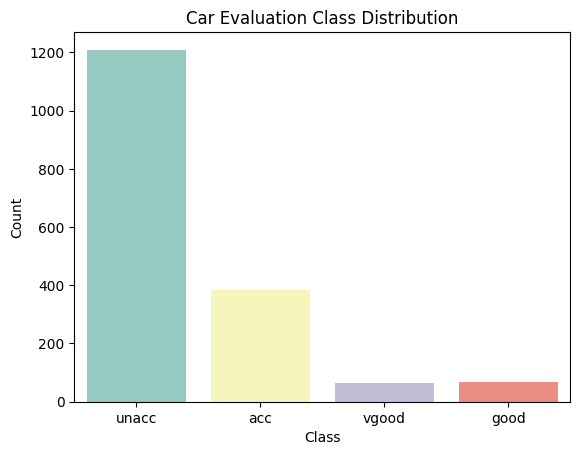

In [20]:
# Cell 3 — Exploratory Data Analysis
print("Class Distribution:")
print(df['class'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

sns.countplot(x='class', data=df, palette='Set3')
plt.title('Car Evaluation Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [21]:
# Cell 4 — Feature Engineering (Ordinal Encoding)
ordinal_maps = {
    'buying' : {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'maint'  : {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'doors'  : {'2': 2, '3': 3, '4': 4, '5more': 5},
    'persons': {'2': 2, '4': 4, 'more': 6},
    'lug_boot': {'small': 1, 'med': 2, 'big': 3},
    'safety' : {'low': 1, 'med': 2, 'high': 3}
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

# Encode target variable
le = LabelEncoder()
df['class_enc'] = le.fit_transform(df['class'])

print("Feature Engineering Done!")
print("\nClasses:", le.classes_)
print("\nAfter Encoding:")
print(df.head())

Feature Engineering Done!

Classes: ['acc' 'good' 'unacc' 'vgood']

After Encoding:
   buying  maint  doors  persons  lug_boot  safety  class  class_enc
0       4      4      2        2         1       2  unacc          2
1       4      4      2        2         1       3  unacc          2
2       4      4      2        2         2       1  unacc          2
3       4      4      2        2         2       2  unacc          2
4       4      4      2        2         2       3  unacc          2


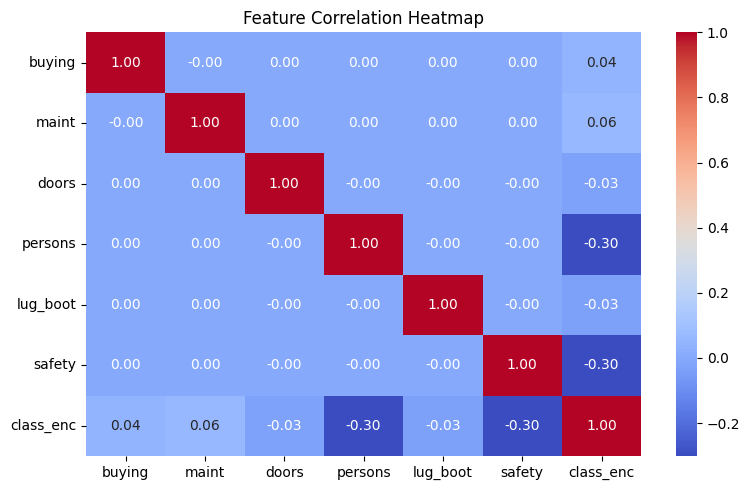

Heatmap plotted!


In [22]:
# Cell 5 — Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.drop('class', axis=1).corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Heatmap plotted!")

In [23]:
# Cell 6 — Train/Test Split
X = df.drop(['class', 'class_enc'], axis=1)
y = df['class_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)
print("\nClass distribution in train:")
print(y_train.value_counts())

Train size: (1381, 6)
Test  size: (346, 6)

Class distribution in train:
class_enc
2    967
0    307
1     55
3     52
Name: count, dtype: int64


In [24]:
# Cell 7 — Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Model trained successfully!")
print(f"Total predictions made: {len(y_pred)}")

Model trained successfully!
Total predictions made: 346


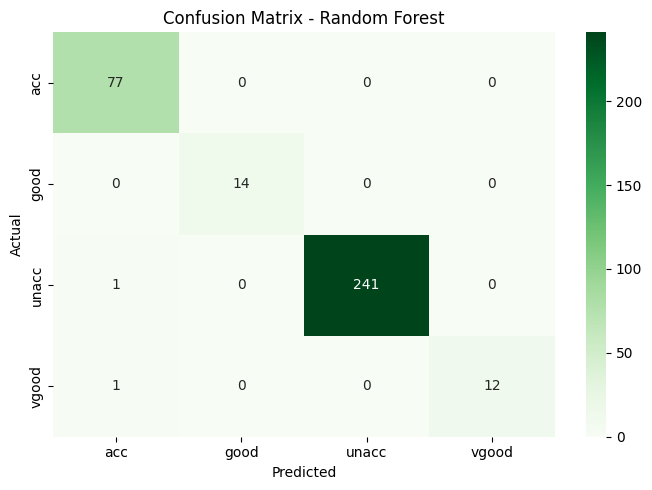

Confusion Matrix:
[[ 77   0   0   0]
 [  0  14   0   0]
 [  1   0 241   0]
 [  1   0   0  12]]


In [25]:
# Cell 8 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [26]:
# Cell 9 — Evaluation Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy  : 0.9942  (99.42%)
Precision : 0.9944
Recall    : 0.9942
F1-Score  : 0.9942

Detailed Report:
              precision    recall  f1-score   support

         acc       0.97      1.00      0.99        77
        good       1.00      1.00      1.00        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.99       346
   macro avg       0.99      0.98      0.99       346
weighted avg       0.99      0.99      0.99       346

